In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [2]:
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes,Malnurished
0,17,22.00,1,1,34,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,40,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,59,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
3,55,21.53,1,1,28,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
4,14,28.03,1,1,26,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [12]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state= 12)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Child_age                        2205 non-null   int64  
 1   BMI                              2205 non-null   float64
 2   Children_under5                  2205 non-null   int64  
 3   Total_children_ever_born         2205 non-null   int64  
 4   Mother_age_current               2205 non-null   int64  
 5   Mother_education_1               2205 non-null   int64  
 6   Mother_education_2               2205 non-null   int64  
 7   Mother_education_3               2205 non-null   int64  
 8   Wealth_index_1                   2205 non-null   int64  
 9   Wealth_index_2                   2205 non-null   int64  
 10  Wealth_index_3                   2205 non-null   int64  
 11  Wealth_index_4                   2205 non-null   int64  
 12  Place_residence_rura

In [15]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

X_train_scaled.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_hill dalit,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes
1541,1.094481,-0.727480,1,1,0.687499,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
32,1.617319,-0.788070,2,1,-0.069640,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
869,0.223085,-1.262249,1,1,-0.258925,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
821,0.513551,1.074402,2,2,-0.826780,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
1934,0.687830,-0.382383,1,1,-0.069640,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [18]:
model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [19]:
y_pred = model.predict(X_test_scaled)
pd.crosstab(y_test, y_pred)

col_0,0,1
Malnurished,,
0,221,59
1,127,34


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.79      0.70       280
           1       0.37      0.21      0.27       161

    accuracy                           0.58       441
   macro avg       0.50      0.50      0.49       441
weighted avg       0.54      0.58      0.54       441



In [22]:
average_precision_score(y_test, y_pred)

0.3651874962233608

In [32]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1180, 1: 584})
After SMOTE:  Counter({0: 1180, 1: 1180})


In [33]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sm, y_train_sm, cv = 9, scoring='recall')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

Best k after balancing: 3, Accuracy: 0.8873


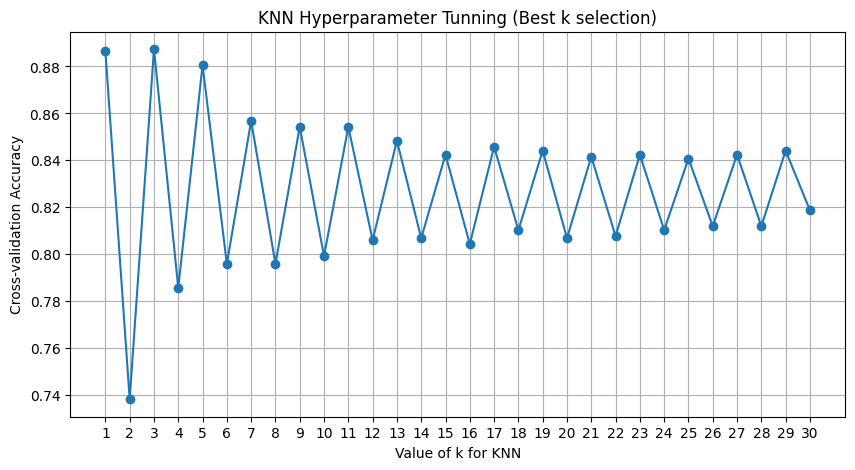

In [34]:
plt.figure(figsize=(10,5))
plt.plot(k_values, cv_scores, marker = 'o')
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-validation Accuracy')
plt.title('KNN Hyperparameter Tunning (Best k selection)')
plt.xticks(range(1,31,1))
plt.grid(True)
plt.show()

In [36]:
knn_combined = KNeighborsClassifier(weights = 'distance', metric = 'manhattan', n_neighbors=3)
knn_combined.fit(X_train_sm, y_train_sm)
y_predict = knn_combined.predict(X_test_scaled)

print(accuracy_score(y_test, y_predict))
pd.crosstab(y_test, y_predict)

0.5056689342403629


col_0,0,1
Malnurished,,
0,151,129
1,89,72


In [37]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.63      0.54      0.58       280
           1       0.36      0.45      0.40       161

    accuracy                           0.51       441
   macro avg       0.49      0.49      0.49       441
weighted avg       0.53      0.51      0.51       441

